In [ ]:
import pandas as pd

df = pd.read_csv("IPL.csv")
print(df.shape)
print(df.columns)
print(df.head(10))


/var/folders/n8/8yg5llq167q0jmvx001j8q5m0000gn/T/ipykernel_8330/2757063091.py:1: DtypeWarning: Columns (0: review_batter, 1: team_reviewed, 2: review_decision, 3: umpire, 4: season, 5: superover_winner, 6: result_type, 7: method, 8: event_match_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL.csv")


(283678, 65)
Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter',
       'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket',
       'batting_partners', 'next_batter', 'st

In [11]:
print(df.describe())

          Unnamed: 0      match_id        innings           over  \
count  283678.000000  2.836780e+05  283678.000000  283678.000000   
mean   141838.500000  9.535684e+05       1.482787       9.190833   
std     81890.929169  3.865091e+05       0.502511       5.680845   
min         0.000000  3.359820e+05       1.000000       0.000000   
25%     70919.250000  5.483590e+05       1.000000       4.000000   
50%    141838.500000  1.082612e+06       1.000000       9.000000   
75%    212757.750000  1.304066e+06       2.000000      14.000000   
max    283677.000000  1.529267e+06       6.000000      19.000000   

                ball        ball_no        bat_pos    runs_batter  \
count  283678.000000  283678.000000  283678.000000  283678.000000   
mean        3.488847       9.539717       3.616445       1.281421   
std         1.708286       5.682271       2.170569       1.655126   
min         1.000000       0.100000       1.000000       0.000000   
25%         2.000000       4.500000       

In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  str    
 3   match_type         283678 non-null  str    
 4   event_name         283678 non-null  str    
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  str    
 7   bowling_team       283678 non-null  str    
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  str    
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  str    
 16  valid_ball   

In [13]:
print(df.isnull().sum())

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         270085
striker_out              0
Length: 65, dtype: int64


## 1. Top 10 IPL Run Scorers (All Time)

Virat Kohli leads with 8899 runs, nearly 1700 ahead of Rohit Sharma. Both are 
still active players, which explains why they're ahead of retired greats like 
Gayle and Raina — they've simply played more seasons recently to add to their tally.

batter
V Kohli           8899
RG Sharma         7185
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5346
AM Rahane         5184
AB de Villiers    5181
CH Gayle          4997
Name: runs_batter, dtype: int64


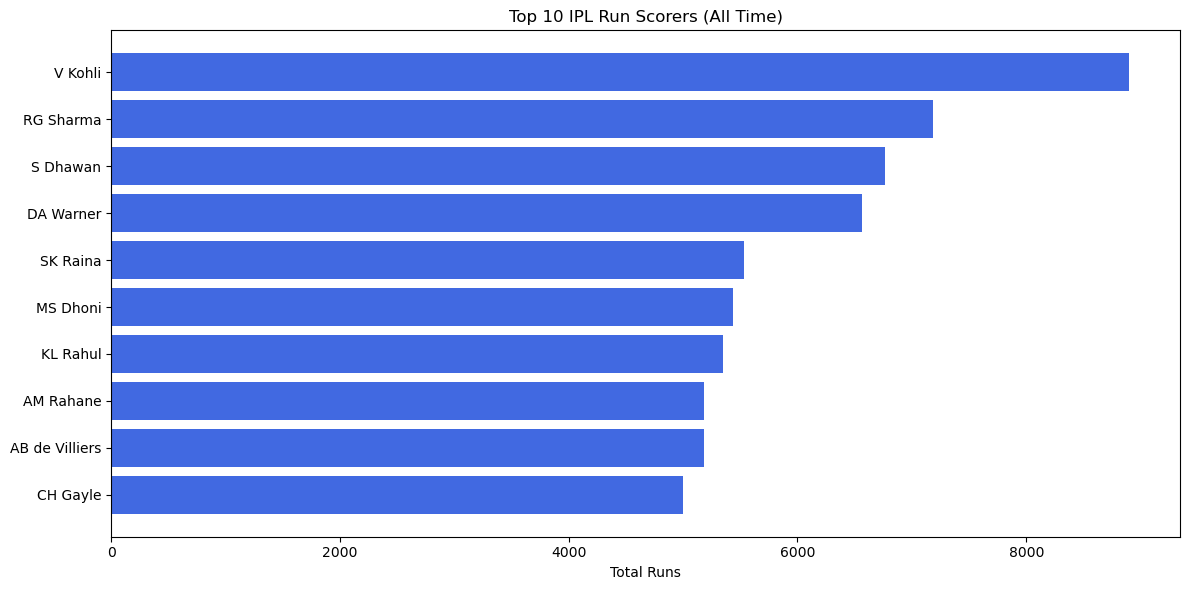

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

top_scorers = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)
print(top_scorers)

plt.figure(figsize=(12,6))
plt.barh(top_scorers.index, top_scorers.values, color='royalblue')
plt.xlabel('Total Runs')
plt.title('Top 10 IPL Run Scorers (All Time)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_scorers.png')
plt.show()

## 2. Top 10 IPL Wicket Takers (All Time)

Yuzvendra Chahal leads the all-time wicket-taking charts, followed closely by Piyush Chawla and Dwayne Bravo. The list is dominated by experienced bowlers who have consistently performed across multiple IPL seasons, highlighting the importance of longevity and consistency in becoming one of the league's highest wicket-takers.

bowler
YS Chahal     233
B Kumar       220
SP Narine     215
DJ Bravo      207
R Ashwin      205
JJ Bumrah     204
PP Chawla     201
SL Malinga    188
A Mishra      183
RA Jadeja     182
Name: wicket_kind, dtype: int64


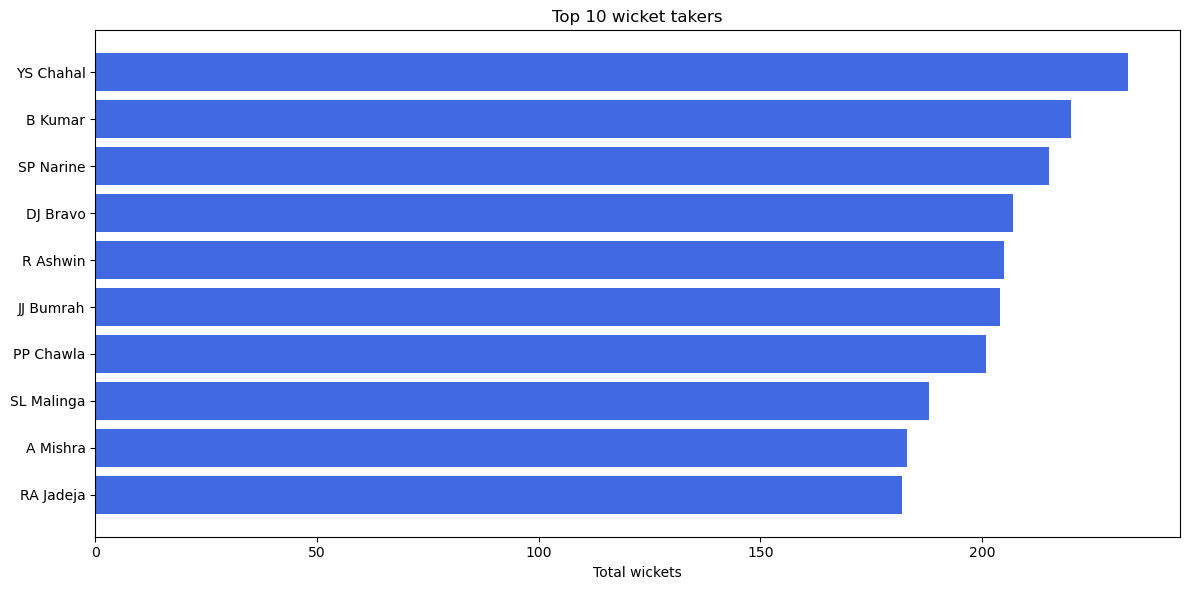

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

wicket = df[((df['wicket_kind'].notna()) & (df['wicket_kind'] != '0'))]
top_wickets = wicket.groupby('bowler')['wicket_kind'].count().sort_values(ascending=False)
print(top_wickets.head(10))

plt.figure(figsize=(12,6))
plt.barh(top_wickets.head(10).index, top_wickets.head(10).values , color = 'royalblue')
plt.xlabel('Total wickets')
plt.title('Top 10 wicket takers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Top_10_wicket_takers.png')
plt.show()

## 3. Team with the Highest Win Percentage

Mumbai Indians have the highest win percentage among all IPL teams, reflecting their consistent performances across multiple seasons. Their balanced squad, strong leadership over the years, and ability to perform in crucial matches have made them one of the most successful franchises in IPL history.

match_won_by
Mumbai Indians           13.002566
Chennai Super Kings      12.318221
Kolkata Knight Riders    11.548332
Rajasthan Royals         10.094098
Lucknow Super Giants      2.737382
Kochi Tuskers Kerala      0.513259
Delhi                    10.265184
Bengaluru                11.633875
Pune                      2.309666
Punjab                   10.521814
Hyderabad                10.607357
Gujarat                   4.448246
Name: count, dtype: float64


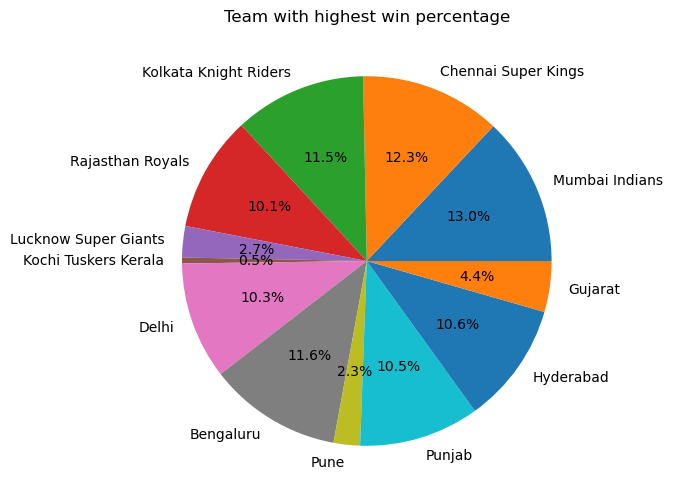

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


wins = df.drop_duplicates(subset='match_id')
wins = wins[wins['match_won_by'] != 'Unknown']
win_counts = wins['match_won_by'].value_counts()
win_counts['Delhi'] = win_counts['Delhi Daredevils'] + win_counts['Delhi Capitals']
win_counts['Bengaluru'] = win_counts['Royal Challengers Bangalore'] + win_counts['Royal Challengers Bengaluru']
win_counts['Pune'] = win_counts['Pune Warriors'] + win_counts['Rising Pune Supergiant'] + win_counts['Rising Pune Supergiants']
win_counts['Punjab'] = win_counts['Kings XI Punjab'] + win_counts['Punjab Kings'] 
win_counts['Hyderabad'] = win_counts['Sunrisers Hyderabad'] + win_counts['Deccan Chargers']
win_counts['Gujarat'] = win_counts['Gujarat Titans'] + win_counts['Gujarat Lions']
win_counts = win_counts.drop([
    'Delhi Daredevils',
    'Delhi Capitals',
    'Royal Challengers Bangalore',
    'Royal Challengers Bengaluru',
    'Pune Warriors',
    'Rising Pune Supergiant',
    'Rising Pune Supergiants',
    'Kings XI Punjab',
    'Punjab Kings',
    'Sunrisers Hyderabad',
    'Deccan Chargers',
    'Gujarat Titans',
    'Gujarat Lions'
])

# print(win_counts.sort_values(ascending=False))
percentage = ((win_counts)/win_counts.sum()) * 100
print(percentage)

plt.figure(figsize=(12,6))
plt.pie(win_counts,labels=win_counts.index,autopct='%1.1f%%')
plt.title('Team with highest win percentage')
plt.savefig('Team_with_highest_win_percentage.png')
plt.show()



## 4. Does Winning the Toss Actually Help You Win the Match?

Winning the toss provides only a slight advantage, as the toss winner does not always go on to win the match. While factors such as pitch conditions and the decision to bat or bowl first can influence the outcome, team performance and execution during the game have a much greater impact on the final result.

luck
True     606
False    563
Name: count, dtype: int64
51.83917878528656


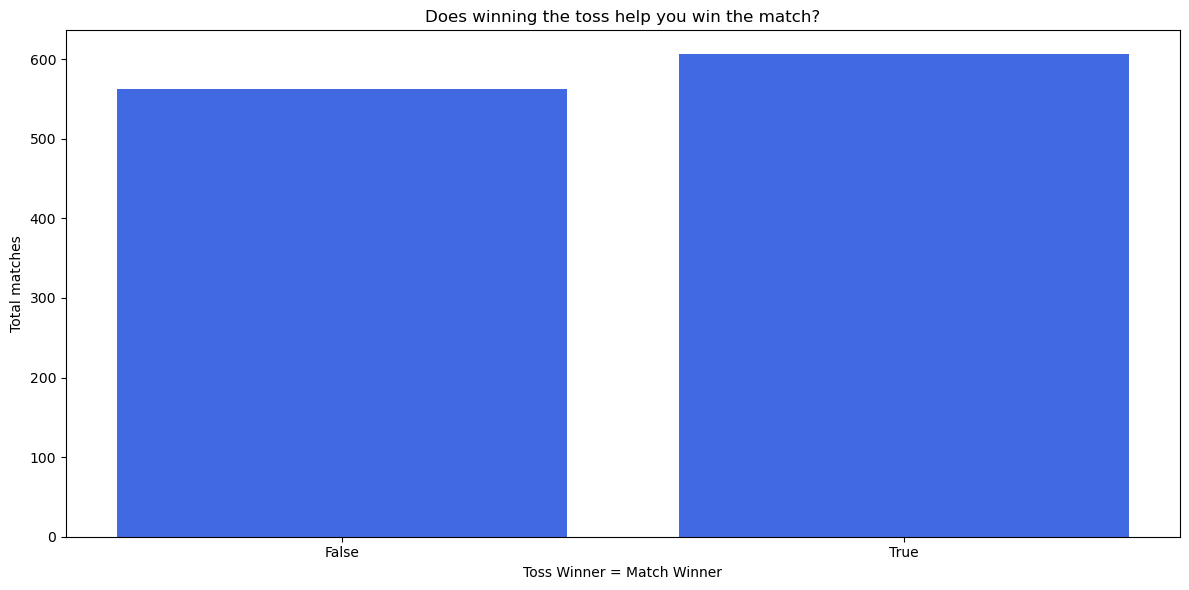

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


matches = df.drop_duplicates(subset='match_id').copy()
matches = matches[matches['match_won_by'] != 'Unknown']
matches['luck'] = matches['match_won_by'] == matches['toss_winner']
count = matches['luck'].value_counts()
print(count)
percentage = matches['luck'].mean() * 100
print(percentage)

plt.figure(figsize=(12,6))
plt.bar(count.index, count.values, color='royalblue')
plt.xticks([0, 1], ['False', 'True'])
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Total matches')
plt.title('Does winning the toss help you win the match?')
plt.tight_layout()
plt.savefig('toss_vs_match_win.png')
plt.show()

## 5. Which Season Had the Highest Total Score per Match?

The highest average total score per match was recorded in the **2024 IPL season**, indicating a clear shift towards high-scoring games. Improved batting depth, aggressive power-hitting, and batting-friendly pitches have contributed to the steady increase in scoring over recent seasons.

season
2025       26527
2024       25971
2023       25688
2022       24395
2013       22602
2012       22453
2011       21154
2018       19901
2019       19434
2020/21    19416
2014       18931
2009/10    18883
2016       18862
2017       18786
2021       18637
2015       18353
2007/08    17937
2009       16353
2026        8567
Name: runs_total, dtype: int64


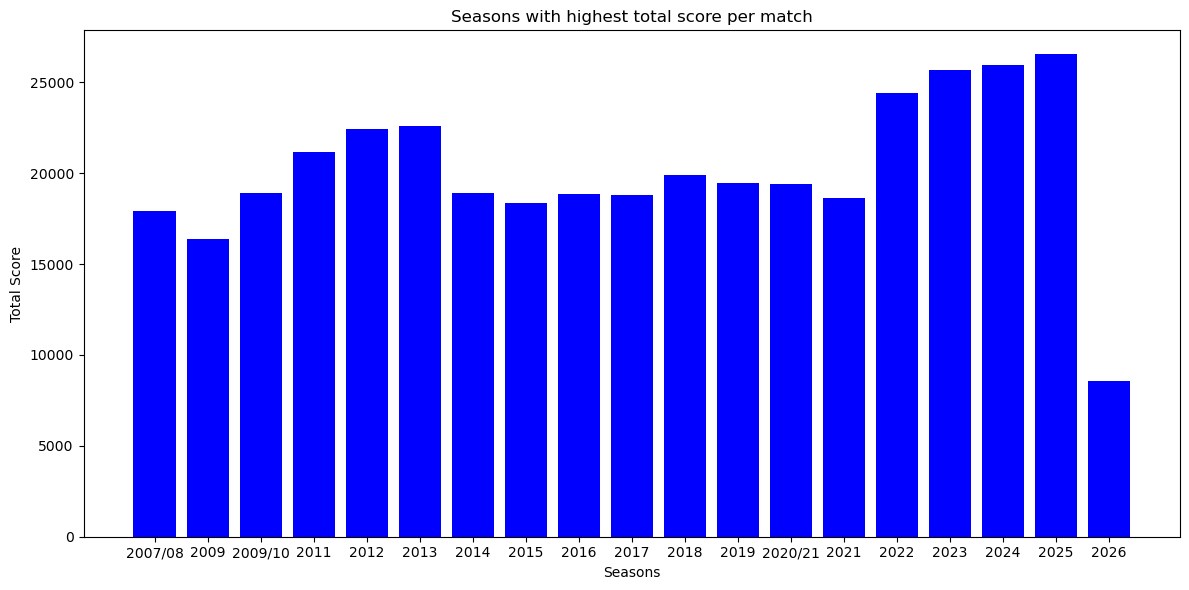

In [6]:
import matplotlib.pyplot as plt

df['season'] = df['season'].astype(str).str.strip()
avg_score = df.groupby('season')['runs_total'].sum()
print(avg_score.sort_values(ascending=False))

plt.figure(figsize=(12,6))
plt.bar(avg_score.index , avg_score.values , color='blue')
plt.xlabel('Seasons')
plt.ylabel('Total Score')
plt.title('Seasons with highest total score per match')
plt.tight_layout()
plt.savefig('Seasons_with_highest_total_score_per_match.png')
plt.show()


In [52]:
print(df['season'].unique())
print(df['batting_team'].unique())

['2007/08' '2009' 2009 '2009/10' '2011' 2011 2012 2013 2014 2015 2016 2017
 2018 2019 '2019' '2020/21' '2021' 2021 2022 2023 2024 2025 2026]
<ArrowStringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bangalore',
         'Chennai Super Kings',             'Kings XI Punjab',
            'Rajasthan Royals',            'Delhi Daredevils',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str
